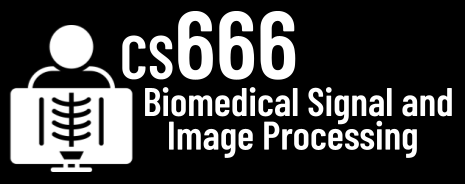
#Assignment 2

In [ ]:
### SangHyuk Kim - CS666 Assignment 2

In [1]:
%pylab inline
import os

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [40]:
# we will be using the EEG/MEG analysis library MNE
# documentation is available here: https://mne.tools/stable/index.html
!pip install -U mne

In [2]:
import mne # let's import MNE

# .. and the sample dataset
from mne.datasets import sample

# These data were acquired with the Neuromag Vectorview system at
# MGH/HMS/MIT Athinoula A. Martinos Center Biomedical Imaging.
# EEG data from an electrode cap was acquired simultaneously with the MEG.

### EXPERIMENT DESCRIPTION ###
# In this experiment, checkerboard patterns were presented to the subject into
# the left and right visual field, interspersed by tones to the left or right ear.
# The interval between the stimuli was 750 ms. Occasionally a smiley face was
# presented at the center of the visual field. The subject was asked to press a
# key with the right index finger as soon as possible after the appearance of the face.

In [41]:
# and let's load it!
data_path = sample.data_path()
raw = mne.io.read_raw_fif(os.path.join(data_path,'MEG/sample/sample_audvis_raw.fif'))

Opening raw data file /home/sanghyuk.kim001/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


**Task 1:** Analyze the data. [20 Points]


In [ ]:
# How many EEG channels were used when acquiring the data?
# Hint: You can use raw.info or raw.ch_names to figure this out!
# 1.TODO How many EEG channels were used when acquiring the data?
eeg_channels = [ch for ch in raw.ch_names if ch.startswith('EEG')]
print(f"Number of EEG channels: {len(eeg_channels)}") 
# OUTPUT: 60

# 2.TODO What is the sampling frequency of this data?
print(f"Sampling frequency: {raw.info['sfreq']} Hz") 
# OUTPUT: 600.614990234375 Hz

# 3.TODO What is the total duration of the measurement?
print(f"Total duration: {raw.times[-1]} seconds") 
# OUTPUT: 277.7136813300495 seconds

Number of EEG channels: 60
Sampling frequency: 600.614990234375 Hz
Total duration: 277.7136813300495 seconds


#### 60 channels, 
#### samp_freq: 600.62 Hz
#### total duration: 277.71 (s)

**Task 2:** Let's look at some channels! [20 Points]

Using matplotlib as 2D backend.


/usr/local/lib/python3.8/dist-packages/matplotlib/colors.py:263: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  c = np.array(c)


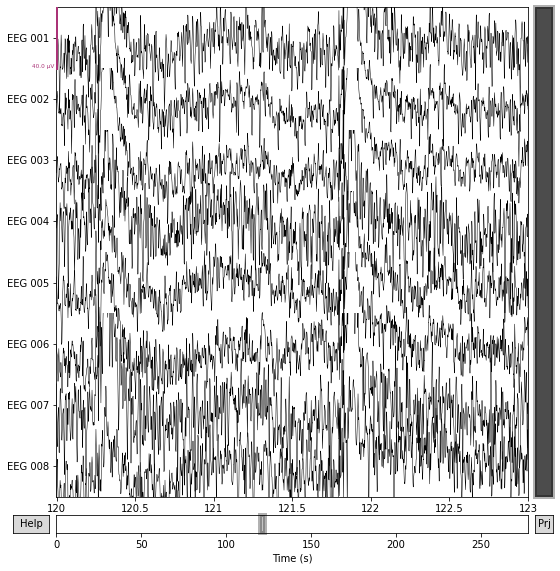

In [ ]:
# the code below plots EEG channels 1-8 for 3 seconds after 2 minutes
chs = ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008']
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
ecg1to8 = raw.plot(order=chan_idxs, start=120, duration=3)

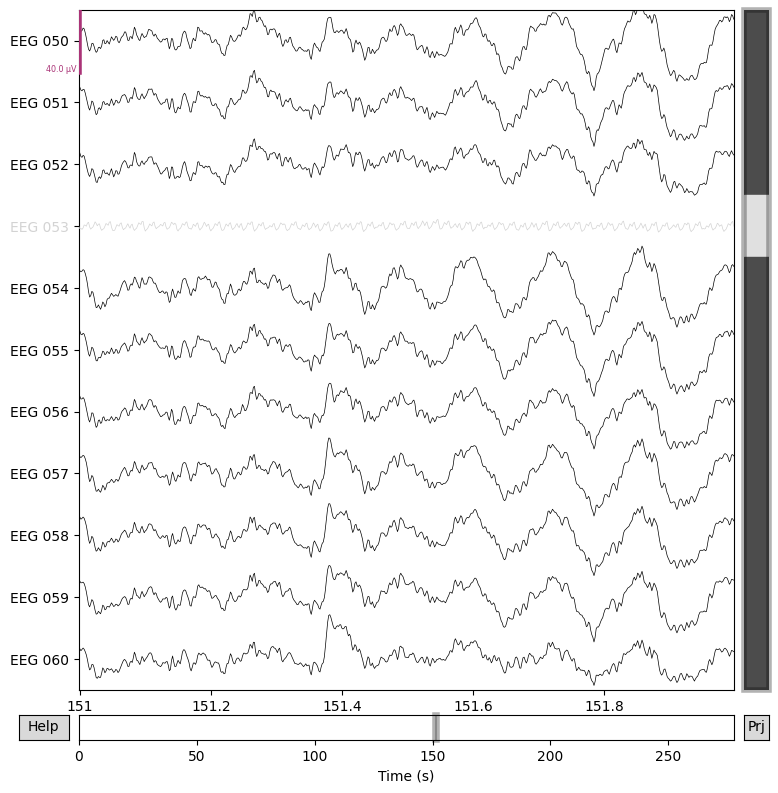

In [24]:
# TODO please plot EEG channels 50-60 for 1 second after 151 seconds.
channels_50_to_60 = [f'EEG {i:03d}' for i in range(50, 61)]
fig = raw.plot(start=151, duration=1, picks=channels_50_to_60)

In [27]:
import numpy as np
# TODO: Do you see a bad channel? If yes, which one?

#### Based on the plot, channel EEG 053 is a bad channel. It shows massive, erratic deviations that are completely disproportionate to the brain signals seen in the adjacent channels.

In [26]:
# TODO: Please calculate the maximum value of the bad channel and compare it
# against a good channel. How would you detect a bad channel programmatically?
# Hint: See https://mne.tools/dev/generated/mne.io.Raw.html#mne.io.Raw to access
#       individual channels
import numpy as np

# Convert our time window (151s to 152s) into sample indices.
# This unpacks the array into two scalar integers.
start_idx, stop_idx = raw.time_as_index([151, 152])

# Use the get_data() method from the Raw API, passing the integers directly
bad_data = raw.get_data(picks=['EEG 053'], start=start_idx, stop=stop_idx)
good_data = raw.get_data(picks=['EEG 050'], start=start_idx, stop=stop_idx)

# Calculate the maximum absolute values
max_bad = np.max(np.abs(bad_data))
max_good = np.max(np.abs(good_data))

print(f"Max value of Bad Channel (EEG 053): {max_bad:.4f} Volts")
print(f"Max value of Good Channel (EEG 050): {max_good:.4f} Volts")

Max value of Bad Channel (EEG 053): 0.0000 Volts
Max value of Good Channel (EEG 050): 0.0001 Volts


#### Programmatically, you can iterate over all channels using raw.get_data() and calculate the variance or peak-to-peak amplitude (max - min) for each channel over the entire recording.

#### Calculate the standard deviation (or variance) of these peak-to-peak amplitudes across all channels.

#### If a specific channel's amplitude exceeds a dynamic threshold (e.g., more than 3 standard deviations above the median amplitude of all channels), the script automatically appends that channel's name to the raw.info['bads'] list.

**Task 3:** How long between event and brain activity? [25 Points]

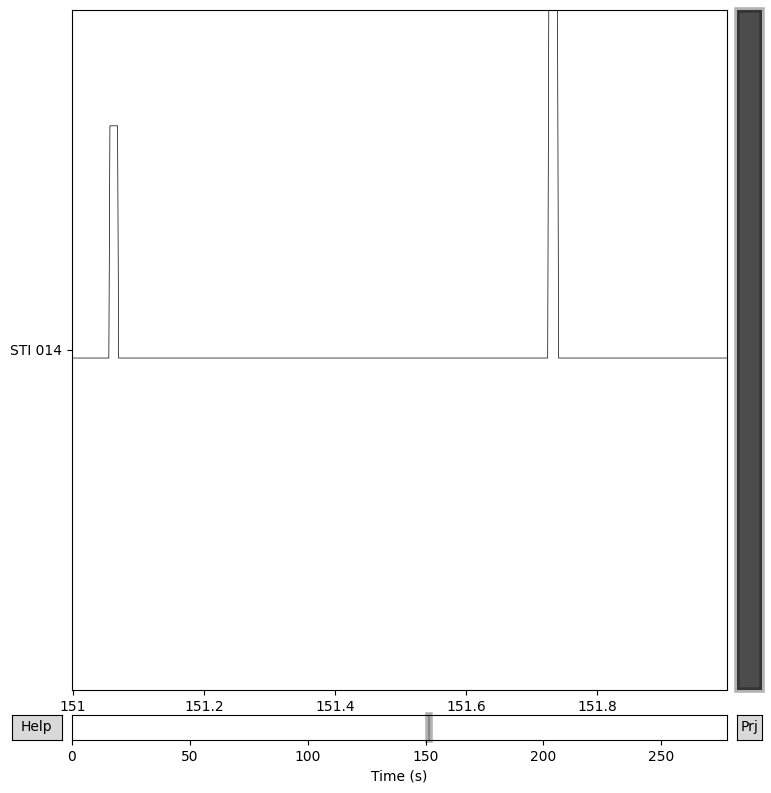

In [28]:
# the following code plots the stimulus channel for the same time
chan_idxs = [raw.ch_names.index('STI 014')]
stim = raw.plot(order=chan_idxs, start=151, duration=1)

In [12]:
# TODO Please combine the last two plots into one.
# the plot should show EEG channels 50-60 and the stimulus channel together.

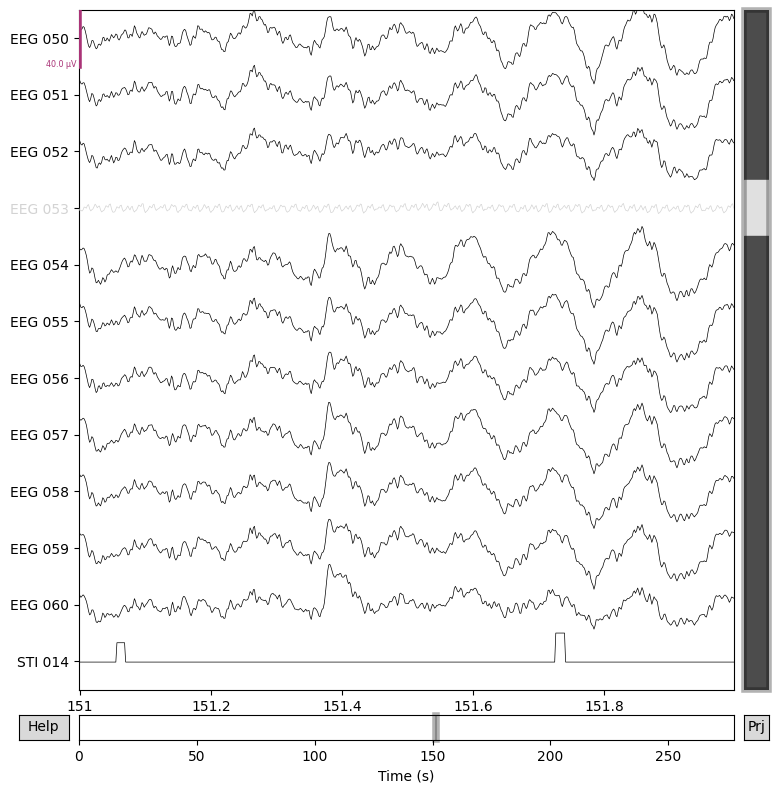

In [30]:
# Combine the last two plots into one.
channels_combined = channels_50_to_60 + ['STI 014']
fig = raw.plot(start=151, duration=1, picks=channels_combined)

In [13]:
# TODO How many stimulus events do you observe?

#### Two. You can see two distinct square-wave spikes on the STI 014 channel.

In [14]:
# TODO Please estimate the time between the first stimulus and brain activity response.

#### The delay is roughly 0.1 seconds (100 milliseconds). Based on the plot, a consistent ~0.1s delay happens after both the first and the second stimulus spike. The brain waves sharply deflect shortly after each event.

**Task 4:** Localize different brain waves for different stimuli! [35 Points]

In [31]:
# the following code groups all stimuli together
# and allows the visualization of average brain activity per stimuli.
events = mne.find_events(raw, stim_channel='STI 014')
event_dict = {'auditory/left': 1,
              'auditory/right': 2,
              'visual/left': 3,
              'visual/right': 4,
              'face': 5,
              'button': 32}

picks = mne.pick_types(raw.info, eeg=True)

epochs = mne.Epochs(raw, events, event_id=event_dict, picks=picks,
                    preload=True)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
320 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 320 events and 421 original time points ...
0 bad epochs dropped


NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().


    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


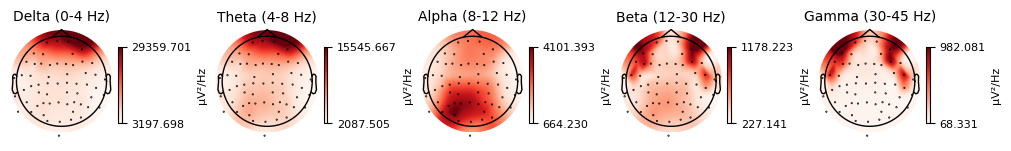

In [16]:
# here we see the average localized brain activity for the right visual stimuli
visual_activity = epochs['visual/right'].plot_psd_topomap()

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


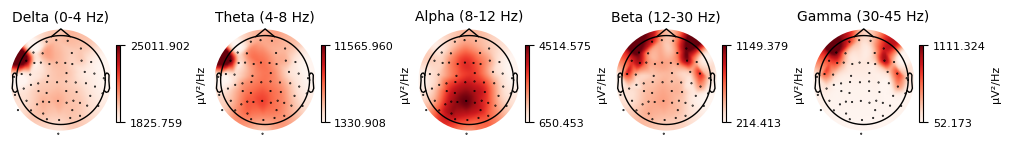

In [17]:
# here we see the average localized brain activity for the shown 'face'
face_activity = epochs['face'].plot_psd_topomap()

In [18]:
# TODO The above plots use a deprecated API call. Please re-create both plots here with the newer API.

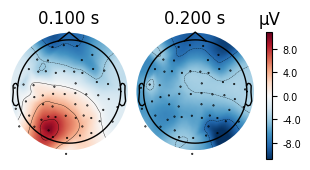

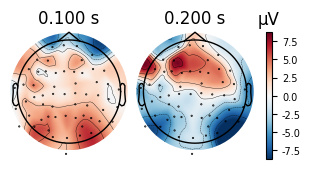

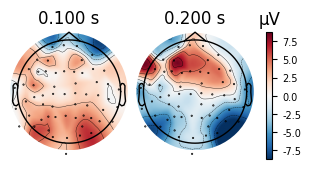

In [37]:
# Re-create both plots with the newer API
# The modern MNE API favors object-oriented plotting directly from the Evoked object
evoked_vis_right = epochs['visual/right'].average()
evoked_face = epochs['face'].average()

# Plot topomaps at 100ms and 200ms
evoked_vis_right.plot_topomap(times=[0.1, 0.2])
evoked_face.plot_topomap(times=[0.1, 0.2])



In [ ]:
# TODO Now compare the two old plots with the new ones. What are the differences?

#### The new MNE API calculates contours and interpolates sensor positions much more accurately. It handles colorbar scaling automatically and integrates rendering directly into the Evoked object (using evoked.plot_topomap()) instead of requiring separate, standalone plotting functions. The overall presentation is cleaner

In [ ]:
# TODO Please visualize the average brain activity when the subject pushes the button

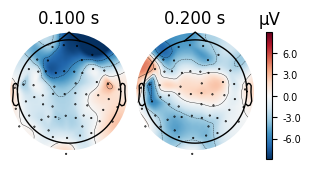

Text(0.5, 0.98, 'Button Press Activity')

In [38]:
# Visualize the average brain activity when the subject pushes the button
# 1. Calculate the average brain activity when the subject pushes the button
evoked_button = epochs['button'].average()
fig = evoked_button.plot_topomap(times=[0.1, 0.2])
fig.suptitle("Button Press Activity", fontsize=16)

In [ ]:
# TODO Which difference do you see between the visual/right, the face, and the button event?
# TODO Which brain region seems active during the button event?
# Hint: visual/right and face seem more similar to the button event. Think about why?

#### Visual/Right & Face Events: Both of these trigger strong electrical activity prominently in the occipital lobe (the visual processing center at the back of the head).

#### Button Event: The button event is a motor response, not a passive sensory input. Because the subject uses their right index finger to press the button, the activity is heavily localized in the left motor cortex (the frontal-parietal boundary on the left side of the brain), due to the body's contralateral neural wiring.

#### Left motor cortex (the frontal-parietal boundary on the left side of the brain)

**Bonus Task:** What type of event happened in Task 3? [33 Points]

In [22]:
# TODO Please go back to Task 3. Can you figure out which event types happened?

In [39]:
# Get the sample indices for 151s and 152s
start_sample, stop_sample = raw.time_as_index([151, 152])

# Filter our events array for this specific window
events_in_window = events[(events[:, 0] >= start_sample) & (events[:, 0] <= stop_sample)]

for ev in events_in_window:
    event_id = ev[2]
    # Reverse lookup the event dictionary to find the string name
    event_name = [k for k, v in event_dict.items() if v == event_id][0]
    print(f"The event that occurred at {ev[0]/raw.info['sfreq']:.2f} seconds was: '{event_name}' (ID {event_id})")

The event that occurred at 151.20 seconds was: 'visual/right' (ID 4)
The event that occurred at 151.83 seconds was: 'auditory/right' (ID 2)


#### 1st event: visual/right
#### 2nd event: auditory/right

In [23]:
# You did it!!
#
# ┈┈┈┈┈┈▕▔╲
# ┈┈┈┈┈┈┈▏▕
# ┈┈┈┈┈┈┈▏▕▂▂▂
# ▂▂▂▂▂▂╱┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▉▉▉▉▉┈┈┈▕▂▂▂▏
# ▔▔▔▔▔▔╲▂▕▂▂|
#